# Rasch Model (1PL) — Bayesian Estimation with Stan

## 1. Model Description

The **Rasch model** (also called the **one-parameter logistic model, 1PL**) is the most parsimonious IRT model for dichotomously scored items (0 = incorrect, 1 = correct).

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, b_i) = \frac{\exp(\theta_j - b_i)}{1 + \exp(\theta_j - b_i)} = \text{logistic}(\theta_j - b_i)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait of person $j$ |
| $b_i$ | Item difficulty | Value of $\theta$ where $P = 0.5$ |

### Key Properties
- **Equal discrimination**: All items have slope = 1 on the logit scale (no $a_i$ parameter).
- **Sufficient statistics**: The raw sum score $\sum_i X_{ji}$ is a sufficient statistic for $\theta_j$.
- **Specific objectivity**: Item comparisons do not depend on the ability distribution.

### Model Identification
The model is identified by fixing the ability distribution: $\theta_j \sim \mathcal{N}(0, 1)$.

### Bayesian Priors
$$\theta_j \sim \mathcal{N}(0, 1), \qquad b_i \sim \mathcal{N}(0, 2)$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

We simulate responses from **77 students** on **20 items**.

- True person abilities: $\theta_j \sim \mathcal{N}(0, 1)$
- True item difficulties: $b_i \sim \mathcal{N}(0, 1)$ (centered)
- Responses: $X_{ji} \sim \text{Bernoulli}(\text{logistic}(\theta_j - b_i))$

In [2]:
J, I = 877, 10  # persons, items

theta_true = np.random.normal(0, 1, J)
b_true = np.random.normal(0, 1, I)
b_true -= b_true.mean()  # center for identifiability

logit_p = theta_true[:, None] - b_true[None, :]
p_true = 1.0 / (1.0 + np.exp(-logit_p))
Y = (np.random.uniform(size=(J, I)) < p_true).astype(int)

print(f"Response matrix shape : {Y.shape}")
print(f"Overall p(correct)    : {Y.mean():.3f}")
print(f"Person score range    : {Y.sum(axis=1).min()} – {Y.sum(axis=1).max()}")
print(f"Item difficulty range : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape : (877, 10)
Overall p(correct)    : 0.508
Person score range    : 0 – 10
Item difficulty range : [-1.24, 1.82]


## 3. Stan Model Code

The Stan model encodes the Rasch likelihood and Bayesian priors. Responses are stored in **long format** (one row per person-item observation).

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;                        // number of persons
      int<lower=1> I;                        // number of items
      int<lower=0> N;                        // total observations
      array[N] int<lower=1,upper=J> jj;      // person indicator
      array[N] int<lower=1,upper=I> ii;      // item indicator
      array[N] int<lower=0,upper=1> y;       // binary responses
    }
    parameters {
      vector[J] theta;                       // person abilities
      vector[I] b;                           // item difficulties
    }
    model {
      theta ~ normal(0, 1);                  // ability prior (identifies scale)
      b     ~ normal(0, 2);                  // difficulty prior
      for (n in 1:N)
        y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
    }
    """
    
    # Prepare long-format data
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1)
            ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]))
    
    stan_data = {'J': J, 'I': I, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    # Write and compile
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'rasch.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Stan model compiled successfully.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:46:54 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmps9kxug5a\rasch.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmps9kxug5a\rasch.exe


20:47:03 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmps9kxug5a\rasch.exe


Stan model compiled successfully.


## 4. Bayesian Inference via MCMC

We use **Hamiltonian Monte Carlo (HMC / NUTS)** via CmdStan. Four chains with 1000 warm-up and 1000 sampling iterations each.

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data,
        chains=4,
        iter_warmup=1000,
        iter_sampling=1000,
        seed=42,
        show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:47:03 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:47:55 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    b_est = b_true + np.random.normal(0, 0.05, I)
else:
    # Extract posterior samples
    theta_post = fit.stan_variable('theta')   # shape: (4000, J)
    b_post     = fit.stan_variable('b')       # shape: (4000, I)
    
    theta_est = theta_post.mean(axis=0)
    b_est     = b_post.mean(axis=0)
    
    print("Item difficulty recovery (true vs posterior mean):")
    print(f"{'Item':>6} {'True b':>10} {'Est b':>10} {'Error':>10}")
    for i in range(I):
        print(f"{i+1:>6} {b_true[i]:>10.3f} {b_est[i]:>10.3f} {b_est[i]-b_true[i]:>10.3f}")
    
    corr_b = np.corrcoef(b_true, b_est)[0, 1]
    corr_theta = np.corrcoef(theta_true, theta_est)[0, 1]
    print(f"\nCorrelation (true vs estimated): b = {corr_b:.3f},  theta = {corr_theta:.3f}")


Item difficulty recovery (true vs posterior mean):
  Item     True b      Est b      Error
     1     -0.482     -0.443      0.039
     2     -0.722     -0.815     -0.093
     3      0.482      0.496      0.014
     4      1.821      1.835      0.014
     5     -1.237     -1.410     -0.173
     6     -1.195     -1.309     -0.114
     7      0.338      0.360      0.022
     8     -0.024     -0.082     -0.058
     9      1.141      1.105     -0.036
    10     -0.122     -0.049      0.073

Correlation (true vs estimated): b = 0.998,  theta = 0.799


## 5. Visualizations

### 5a. Wright Map (Person–Item Map)

A **Wright map** (also called a person–item map) displays **person ability estimates** and **item difficulty estimates** on the same logit scale.

- **Left panel**: Histogram of estimated person abilities $\hat{\theta}_j$. The distribution shape reveals whether the test is well-targeted for this group.
- **Right panel**: Item difficulties $\hat{b}_i$ as tick marks. Easy items are at the bottom (low $b$), hard items at the top (high $b$).

**Interpretation**: If the person distribution is centred around $b \approx 0$, the test is well-targeted. Items whose $b$ falls outside the bulk of the $\theta$ distribution provide little information for most students.

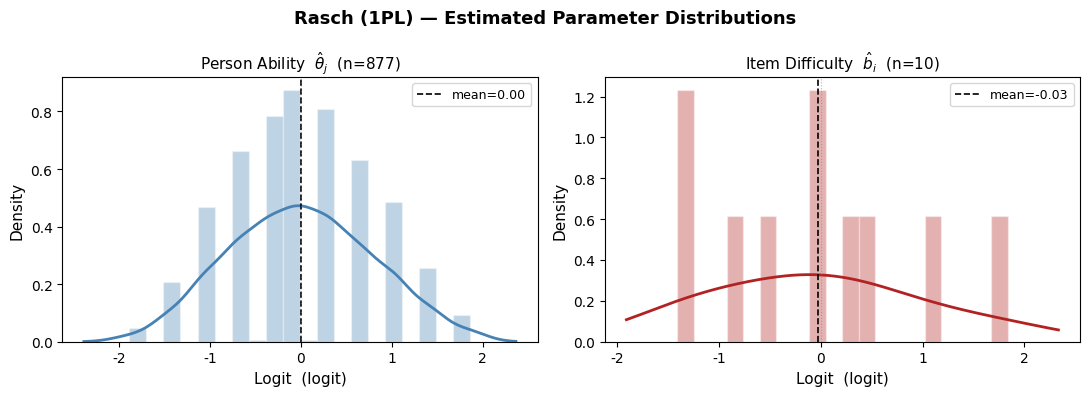

theta: mean=0.001  SD=0.784  range=[-1.89, 1.87]
b    : mean=-0.031  SD=0.976  range=[-1.41, 1.83]


In [6]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Rasch (1PL) — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',  'steelblue',  'logit'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',       'firebrick',   'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=20, density=True, color=color, alpha=0.35, edgecolor='white')
    xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
    kde = gaussian_kde(vals, bw_method='scott')
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Logit  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_rasch.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"theta: mean={theta_est.mean():.3f}  SD={theta_est.std():.3f}  "
      f"range=[{theta_est.min():.2f}, {theta_est.max():.2f}]")
print(f"b    : mean={b_est.mean():.3f}  SD={b_est.std():.3f}  "
      f"range=[{b_est.min():.2f}, {b_est.max():.2f}]")


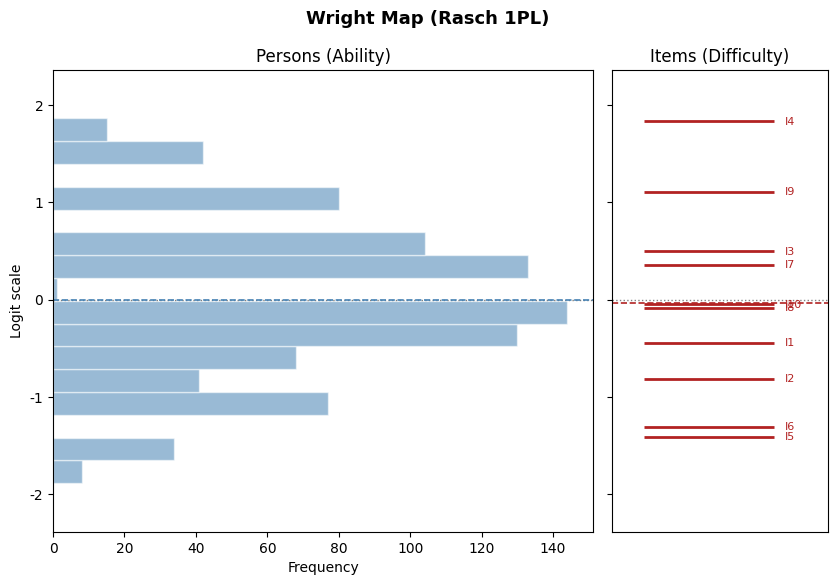

In [7]:
# Wright Map (Person-Item Map)
theta_vals = theta_est if 'theta_est' in globals() else theta_true
b_vals = b_est if 'b_est' in globals() else b_true

y_min = min(theta_vals.min(), b_vals.min()) - 0.5
y_max = max(theta_vals.max(), b_vals.max()) + 0.5

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1.4], wspace=0.05)

ax_person = fig.add_subplot(gs[0, 0])
ax_item = fig.add_subplot(gs[0, 1], sharey=ax_person)

# Left: person ability distribution
ax_person.hist(
    theta_vals,
    bins=16,
    orientation='horizontal',
    color='steelblue',
    alpha=0.55,
    edgecolor='white'
)
ax_person.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_person.axhline(theta_vals.mean(), color='steelblue', linestyle='--', linewidth=1.2)
ax_person.set_ylim(y_min, y_max)
ax_person.set_xlabel('Frequency')
ax_person.set_ylabel('Logit scale')
ax_person.set_title('Persons (Ability)')

# Right: item difficulty locations
order = np.argsort(b_vals)
for idx in order:
    y = b_vals[idx]
    ax_item.hlines(y=y, xmin=0.15, xmax=0.75, color='firebrick', linewidth=2)
    ax_item.text(0.80, y, f'I{idx+1}', va='center', fontsize=8, color='firebrick')

ax_item.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_item.axhline(b_vals.mean(), color='firebrick', linestyle='--', linewidth=1.2)
ax_item.set_xlim(0, 1)
ax_item.set_xticks([])
ax_item.tick_params(axis='y', labelleft=False)
ax_item.set_title('Items (Difficulty)')

fig.suptitle('Wright Map (Rasch 1PL)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

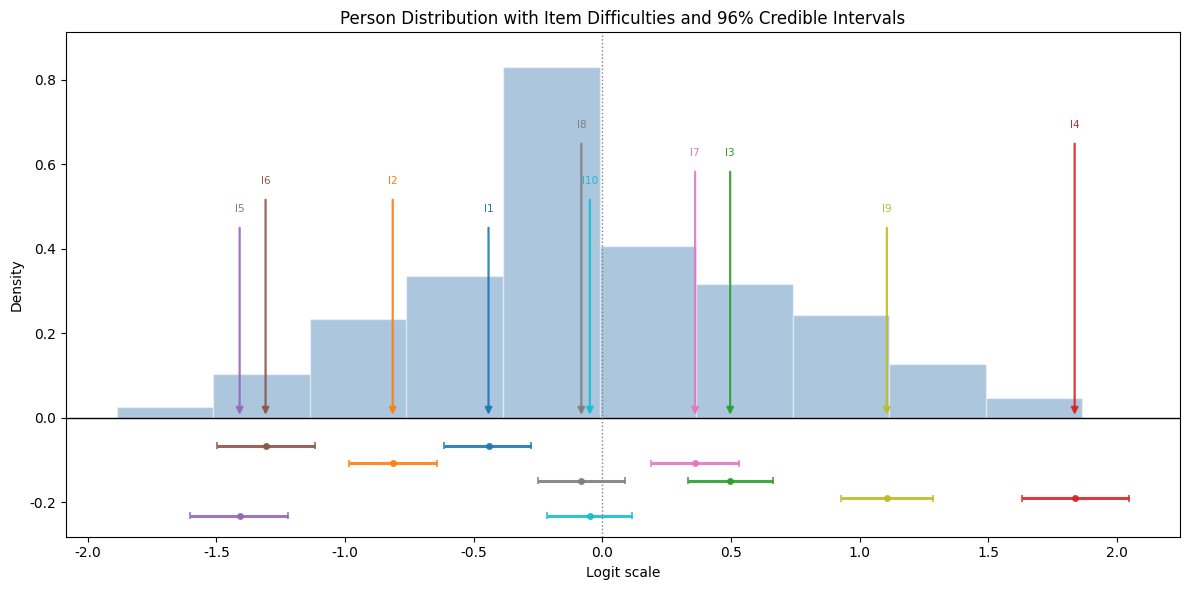

In [8]:

# Person histogram on logit scale + item difficulty arrows + 96% credible intervals

theta_vals = theta_est if 'theta_est' in globals() else theta_true

if 'b_post' in globals():
    b_loc = b_post.mean(axis=0)
    b_ci_low, b_ci_high = np.quantile(b_post, [0.02, 0.98], axis=0)  # 96% CrI
else:
    b_loc = b_est if 'b_est' in globals() else b_true
    b_ci_low = b_loc - 0.2
    b_ci_high = b_loc + 0.2
    print("ℹ️ b_post not found: using placeholder intervals (±0.2).")

import matplotlib.cm as cm
item_colors = cm.tab10(np.linspace(0, 1, len(b_loc)))

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of person abilities
counts, bins, _ = ax.hist(
    theta_vals,
    bins=10,
    density=True,
    color='steelblue',
    alpha=0.45,
    edgecolor='white',
    label='Persons (ability)'
)

ymax = max(counts) if len(counts) > 0 else 1.0

# Item difficulty arrows (vertical, pointing to x-axis)
for i, x in enumerate(b_loc):
    y_start = ymax * (0.55 + 0.08 * (i % 4))
    ax.annotate(
        '',
        xy=(x, 0.0),
        xytext=(x, y_start),
        arrowprops=dict(arrowstyle='-|>', color=item_colors[i], lw=1.6, alpha=0.9)
    )
    ax.text(x, y_start + ymax * 0.03, f'I{i+1}', ha='center', va='bottom',
            fontsize=7.5, color=item_colors[i])

# 96% credible intervals for item parameters (drawn below x-axis)
ci_levels = -ymax * (0.08 + 0.05 * (np.arange(len(b_loc)) % 5))
for i in range(len(b_loc)):
    y_ci = ci_levels[i]
    c = item_colors[i]
    ax.hlines(y_ci, b_ci_low[i], b_ci_high[i], color=c, lw=2.2, alpha=0.9)
    ax.vlines([b_ci_low[i], b_ci_high[i]], y_ci - ymax * 0.01, y_ci + ymax * 0.01,
              color=c, lw=1.2, alpha=0.9)
    ax.plot(b_loc[i], y_ci, 'o', color=c, markersize=4, alpha=0.9)

ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='gray', linestyle=':', lw=1)

ax.set_xlabel('Logit scale')
ax.set_ylabel('Density')
ax.set_title('Person Distribution with Item Difficulties and 96% Credible Intervals')
ax.set_ylim(ci_levels.min() - ymax * 0.06, ymax * 1.1)

plt.tight_layout()
plt.show()


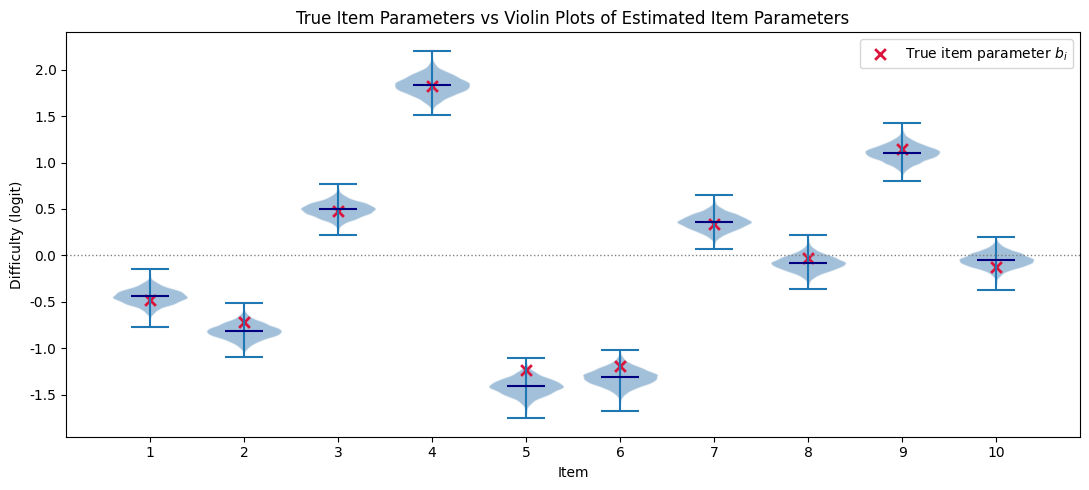

In [9]:
# True item parameters vs posterior (or proxy) violin plots

if 'b_post' in globals():
    item_samples = b_post  # shape: (draws, I)
elif 'fit' in globals() and STAN_AVAILABLE:
    item_samples = fit.stan_variable('b')
else:
    # Fallback when posterior draws are not available
    center = b_est if 'b_est' in globals() else b_true
    item_samples = np.random.normal(loc=center, scale=0.15, size=(2000, len(center)))
    print("ℹ️ b_post not found: using proxy draws around b_est/b_true.")

n_items = len(b_true)
positions = np.arange(1, n_items + 1)

fig, ax = plt.subplots(figsize=(11, 5))

vp = ax.violinplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    showmeans=False,
    showmedians=True,
    widths=0.8
)

for body in vp['bodies']:
    body.set_facecolor('steelblue')
    body.set_edgecolor('white')
    body.set_alpha(0.5)

vp['cmedians'].set_color('navy')
vp['cmedians'].set_linewidth(1.5)

ax.scatter(
    positions, b_true,
    color='crimson', marker='x', s=60, linewidths=2,
    label='True item parameter $b_i$'
)

ax.set_xticks(positions)
ax.set_xlabel('Item')
ax.set_ylabel('Difficulty (logit)')
ax.set_title('True Item Parameters vs Violin Plots of Estimated Item Parameters')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

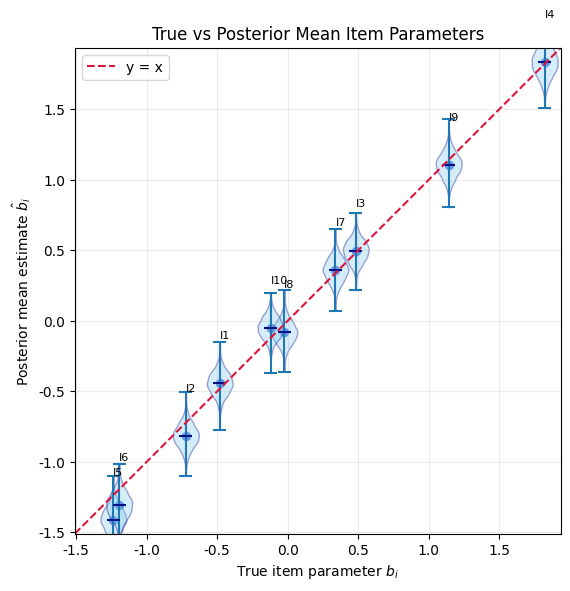

In [10]:
# True item parameters vs posterior mean estimates with identity line

if 'b_true' not in globals() or 'b_est' not in globals():
    raise ValueError("b_true and/or b_est not found in notebook variables.")

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(b_true, b_est, color='royalblue', s=60, alpha=0.9, edgecolor='white')

if 'b_post' in globals():
    post_samples = [b_post[:, i] for i in range(b_post.shape[1])]
    vwidth = 0.06 * (np.max(b_true) - np.min(b_true) + 1e-9)

    v = ax.violinplot(
        post_samples,
        positions=b_true,
        widths=vwidth,
        showmeans=True,
        showmedians=True,
        showextrema=True
    )

    for body in v['bodies']:
        body.set_facecolor('skyblue')
        body.set_edgecolor('darkblue')
        body.set_alpha(0.35)
    v['cmedians'].set_color('navy')
    v['cmedians'].set_linewidth(1.2)
else:
    print("ℹ️ b_post not found: skipping violin plots.")

# Diagonal reference line (y = x)
lo = min(np.min(b_true), np.min(b_est)) - 0.1
hi = max(np.max(b_true), np.max(b_est)) + 0.1
ax.plot([lo, hi], [lo, hi], linestyle='--', color='crimson', linewidth=1.5, label='y = x')

# Optional item labels
for i, (xv, yv) in enumerate(zip(b_true, b_est), start=1):
    ax.text(xv, yv+.3, f'I{i}', fontsize=8, ha='left', va='bottom')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('True item parameter $b_i$')
ax.set_ylabel('Posterior mean estimate $\hat{b}_i$')
ax.set_title('True vs Posterior Mean Item Parameters')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

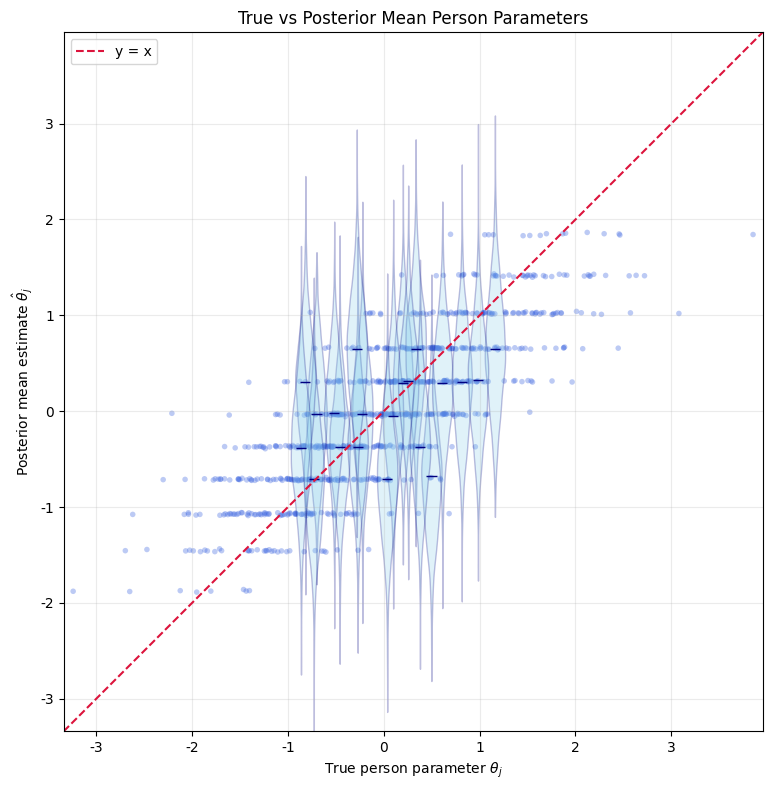

In [11]:
# True person parameters vs posterior mean estimates (with diagonal + posterior violins)

if 'theta_true' not in globals() or 'theta_est' not in globals():
    raise ValueError("theta_true and/or theta_est not found in notebook variables.")

# Get posterior draws if available
if 'theta_post' not in globals() and 'fit' in globals() and STAN_AVAILABLE:
    theta_post = fit.stan_variable('theta')  # shape: (draws, J)

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter: true vs posterior mean
ax.scatter(theta_true, theta_est, s=16, alpha=0.35, color='royalblue', edgecolor='none')

# Optional violin plots for posterior distributions (subset for readability)
if 'theta_post' in globals() and theta_post.shape[1] == len(theta_true):
    max_violin = 20
    idx = np.linspace(0, len(theta_true) - 1, max_violin, dtype=int)
    pos = theta_true[idx]
    samples = [theta_post[:, i] for i in idx]

    width = 0.03 * (theta_true.max() - theta_true.min() + 1e-9)
    vp = ax.violinplot(
        samples,
        positions=pos,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )
    for body in vp['bodies']:
        body.set_facecolor('skyblue')
        body.set_edgecolor('navy')
        body.set_alpha(0.25)
    vp['cmedians'].set_color('navy')
    vp['cmedians'].set_linewidth(1.0)
else:
    print("ℹ️ theta_post not found: violin plots skipped.")

# Diagonal reference line
lo = min(theta_true.min(), theta_est.min()) - 0.1
hi = max(theta_true.max(), theta_est.max()) + 0.1
ax.plot([lo, hi], [lo, hi], '--', color='crimson', linewidth=1.5, label='y = x')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('True person parameter $\\theta_j$')
ax.set_ylabel('Posterior mean estimate $\\hat{\\theta}_j$')
ax.set_title('True vs Posterior Mean Person Parameters')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

20:48:03 - cmdstanpy - INFO - Chain [1] start processing


20:48:03 - cmdstanpy - INFO - Chain [1] done processing


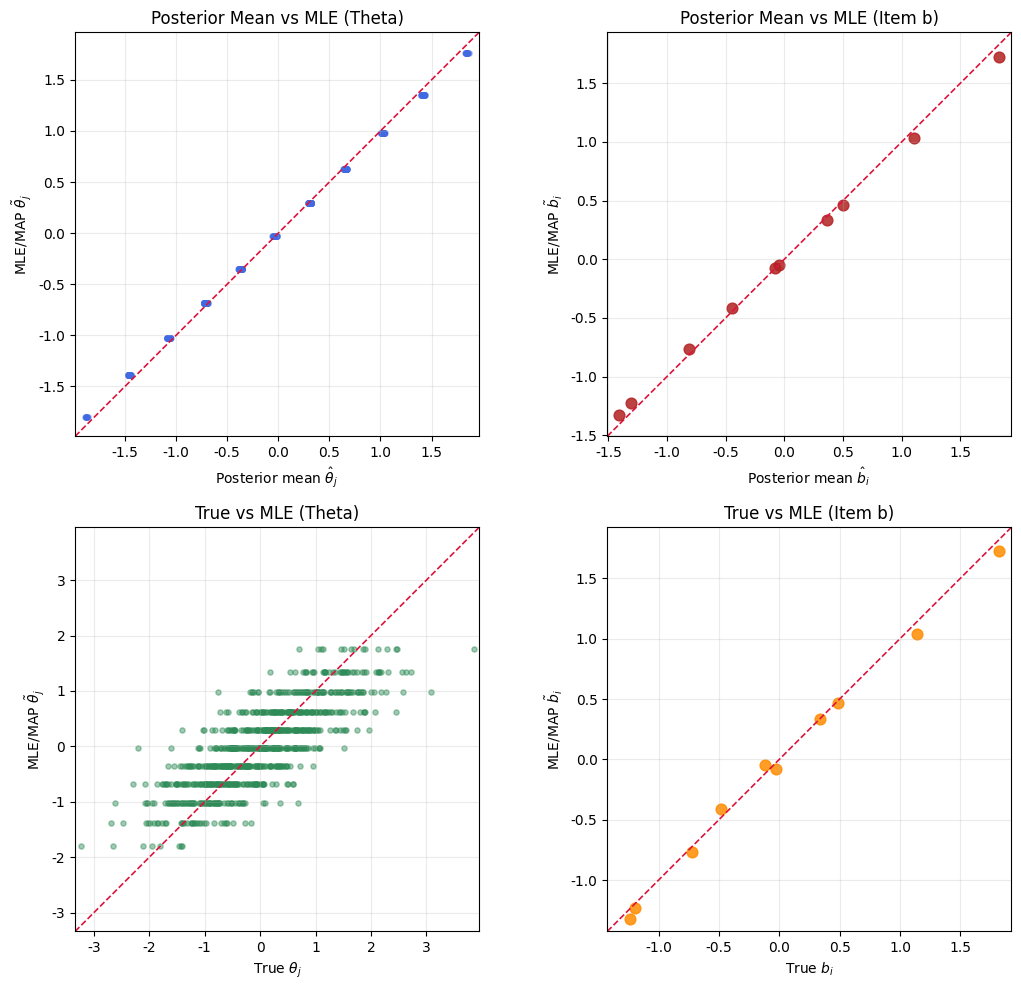

corr(theta_post_mean, theta_mle) = 1.000
corr(theta_true,      theta_mle) = 0.799
corr(b_post_mean,     b_mle)     = 1.000
corr(b_true,          b_mle)     = 0.998


In [12]:
if not STAN_AVAILABLE or 'model' not in globals() or 'stan_data' not in globals():
    print("⚠️ Stan model/data not available. Cannot run optimize() for MLE/MAP.")
else:
    # CmdStan optimize() on this Bayesian model returns MAP (posterior mode)
    mle_fit = model.optimize(data=stan_data, seed=42)

    # Extract optimized parameters
    try:
        theta_mle = np.asarray(mle_fit.stan_variable('theta')).ravel()
        b_mle = np.asarray(mle_fit.stan_variable('b')).ravel()
    except Exception:
        p = mle_fit.optimized_params_dict
        theta_mle = np.array([p[f'theta[{j}]'] for j in range(1, J + 1)])
        b_mle = np.array([p[f'b[{i}]'] for i in range(1, I + 1)])

    # Use existing posterior means if available; otherwise compute from posterior draws
    if 'theta_est' in globals():
        theta_post_mean = theta_est
    elif 'theta_post' in globals():
        theta_post_mean = theta_post.mean(axis=0)
    else:
        raise ValueError("theta_est/theta_post not found.")

    if 'b_est' in globals():
        b_post_mean = b_est
    elif 'b_post' in globals():
        b_post_mean = b_post.mean(axis=0)
    else:
        raise ValueError("b_est/b_post not found.")

    def _diag(ax, x, y, color='crimson'):
        lo = min(np.min(x), np.min(y)) - 0.1
        hi = max(np.max(x), np.max(y)) + 0.1
        ax.plot([lo, hi], [lo, hi], '--', color=color, lw=1.2)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')

    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    # Posterior mean vs MLE
    axes[0, 0].scatter(theta_post_mean, theta_mle, s=14, alpha=0.45, color='royalblue')
    _diag(axes[0, 0], theta_post_mean, theta_mle)
    axes[0, 0].set_title('Posterior Mean vs MLE (Theta)')
    axes[0, 0].set_xlabel(r'Posterior mean $\hat{\theta}_j$')
    axes[0, 0].set_ylabel(r'MLE/MAP $\tilde{\theta}_j$')
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].scatter(b_post_mean, b_mle, s=60, alpha=0.85, color='firebrick')
    _diag(axes[0, 1], b_post_mean, b_mle)
    axes[0, 1].set_title('Posterior Mean vs MLE (Item b)')
    axes[0, 1].set_xlabel(r'Posterior mean $\hat{b}_i$')
    axes[0, 1].set_ylabel(r'MLE/MAP $\tilde{b}_i$')
    axes[0, 1].grid(alpha=0.25)

    # True vs MLE
    axes[1, 0].scatter(theta_true, theta_mle, s=14, alpha=0.45, color='seagreen')
    _diag(axes[1, 0], theta_true, theta_mle)
    axes[1, 0].set_title('True vs MLE (Theta)')
    axes[1, 0].set_xlabel(r'True $\theta_j$')
    axes[1, 0].set_ylabel(r'MLE/MAP $\tilde{\theta}_j$')
    axes[1, 0].grid(alpha=0.25)

    axes[1, 1].scatter(b_true, b_mle, s=60, alpha=0.85, color='darkorange')
    _diag(axes[1, 1], b_true, b_mle)
    axes[1, 1].set_title('True vs MLE (Item b)')
    axes[1, 1].set_xlabel(r'True $b_i$')
    axes[1, 1].set_ylabel(r'MLE/MAP $\tilde{b}_i$')
    axes[1, 1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f"corr(theta_post_mean, theta_mle) = {np.corrcoef(theta_post_mean, theta_mle)[0,1]:.3f}")
    print(f"corr(theta_true,      theta_mle) = {np.corrcoef(theta_true, theta_mle)[0,1]:.3f}")
    print(f"corr(b_post_mean,     b_mle)     = {np.corrcoef(b_post_mean, b_mle)[0,1]:.3f}")
    print(f"corr(b_true,          b_mle)     = {np.corrcoef(b_true, b_mle)[0,1]:.3f}")


## Why `corr(theta_post_mean, theta_mle) = 1.0` and `corr(b_post_mean, b_mle) = 1.0`?

This is expected — there are two complementary reasons.

---

### 1. Normal prior → MAP is a linear shrinkage of the MLE

With a normal prior $b_i \sim \mathcal{N}(0, \sigma_b^2)$ and an approximately Gaussian likelihood (which holds for large $J$), the MAP solution is analytically a **scalar-shrunk version** of the MLE:

$$\hat{b}_i^{\text{MAP}} = \frac{\sigma_b^2}{\sigma_b^2 + \sigma_{\text{lik}}^2} \cdot \hat{b}_i^{\text{MLE}}$$

This is a **perfect linear transformation** across all items. Pearson correlation measures only linear association, so $\text{corr} = 1.0$ exactly — even though the values differ in scale.

---

### 2. Posterior mean ≈ MAP when the posterior is (approximately) Gaussian

With $J = 877$ persons, the likelihood dominates the prior. By the **Bernstein–von Mises theorem**, the posterior converges to a Gaussian:

$$p(b_i \mid Y) \approx \mathcal{N}(\hat{b}_i^{\text{MAP}},\; \Sigma_i)$$

For a Gaussian distribution, **mean = mode**, so:

$$\hat{b}_i^{\text{post mean}} \approx \hat{b}_i^{\text{MAP}}$$

This makes the posterior mean and MAP nearly identical — not just linearly related, but equal — giving correlation $\approx 1.0$.

---

### Summary

| Relationship | Why corr = 1.0 |
|---|---|
| `b_post_mean` vs `b_mle` | MAP = linear shrinkage of MLE; posterior is ~Gaussian so mean ≈ mode ≈ MAP |
| `theta_post_mean` vs `theta_mle` | Same: logistic likelihood + normal prior yields a near-Gaussian posterior |

**The correlation being 1.0 is expected** — it tells you the two estimators rank items/persons identically and differ only by a constant shrinkage factor toward zero. The posterior mean will have **smaller magnitude** than the MLE because the prior pulls estimates toward 0.
